<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2015/%20%5BLab_15%5D_From_Regression_to_Machine_Learning_%E2%80%94_The_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [2]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


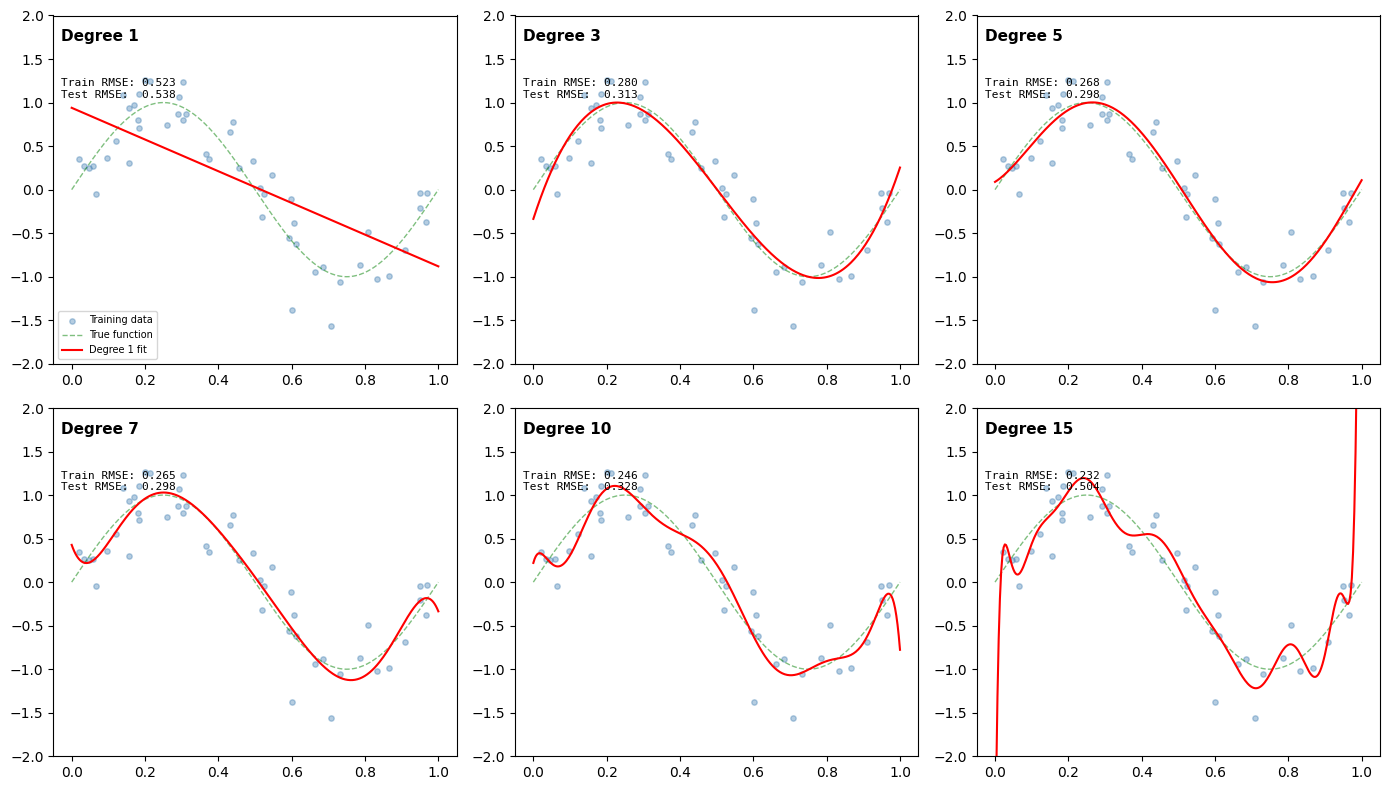

In [3]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

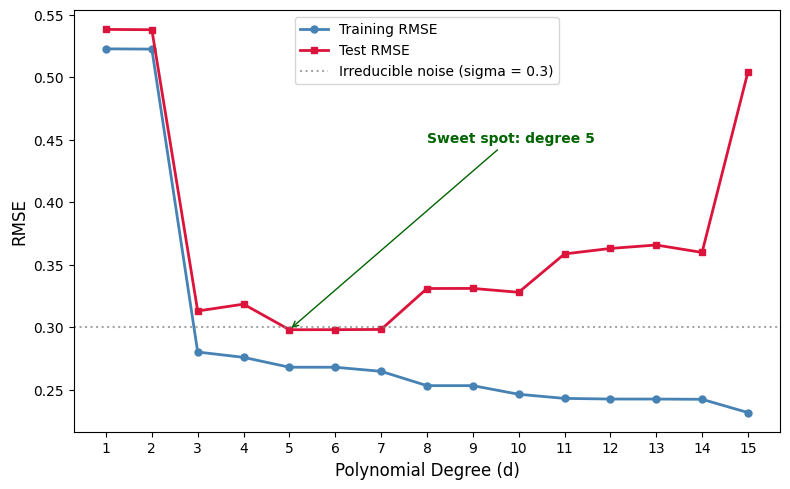

In [4]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = fold[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(___)
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [6]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')


sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


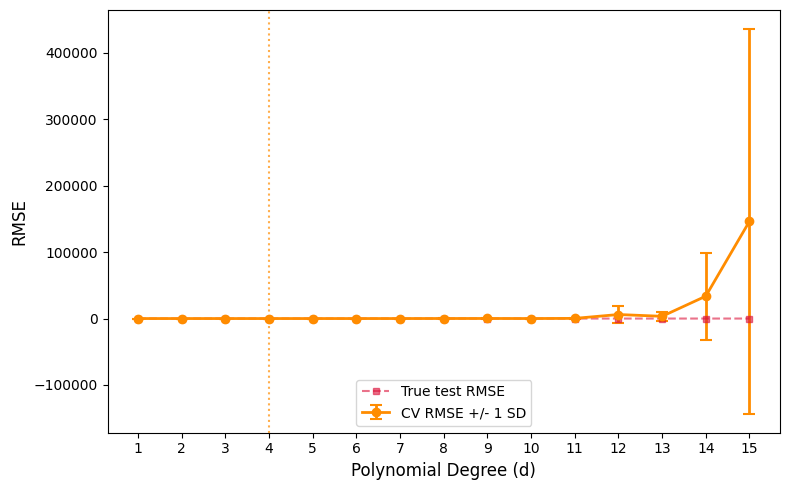

CV-selected degree: 4
True optimal degree: 5


In [7]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [8]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [9]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


Reflection Question: Which model would you deploy to predict house prices for new listings? Why? Use the concepts from today's lecture (bias, variance, generalization gap, CV) in your answer.

Answer:
I'd go with the kitchen sink model (all 37 features). It has a lower CV RMSE (aournd 39k vs around 42k), which means it makes better predictions on data it hasn't seen before.
Because of using more featuresthe kitchen sink model has a bit higher standard deviation. But with only 37 features and over 1,000 observations, we're not in overfitting territory. The simple model drops 32 potentially useful predictors, so dropping them introduces unnecessary bias.

AI-Assisted Expansion
Expansion Task: Build an interactive Streamlit dashboard that lets users explore the bias-variance tradeoff in real time. The dashboard should let users adjust polynomial degree with a slider, toggle between different noise levels, and visualize the complexity curve updating live. Add a panel showing the bias-variance decomposition estimated via repeated sampling.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')
print('Setup complete ✓')

Setup complete ✓


In [19]:
def true_function(x):
    return np.sin(2 * np.pi * x)

def fit_poly(d, x_tr, y_tr):
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression(),
    )
    model.fit(x_tr.reshape(-1, 1), y_tr)
    return model

def bootstrap_bv(n_train, noise_std, seed, n_boot=100):
    rng = np.random.RandomState(int(seed))
    x_tr = np.sort(rng.uniform(0, 1, n_train))
    y_tr = true_function(x_tr) + rng.normal(0, noise_std, n_train)
    x_eval = np.linspace(0, 1, 200)
    y_true_eval = true_function(x_eval)
    bias2_arr, var_arr, mse_arr = [], [], []
    for d in range(1, 16):
        preds = np.zeros((n_boot, len(x_eval)))
        for b in range(n_boot):
            idx = rng.choice(n_train, n_train, replace=True)
            m = fit_poly(d, x_tr[idx], y_tr[idx])
            preds[b] = m.predict(x_eval.reshape(-1, 1))
        mean_pred = preds.mean(axis=0)
        bias2 = np.mean((mean_pred - y_true_eval) ** 2)
        variance = np.mean(preds.var(axis=0))
        mse = bias2 + variance + noise_std ** 2
        bias2_arr.append(bias2)
        var_arr.append(variance)
        mse_arr.append(mse)
    return np.array(bias2_arr), np.array(var_arr), np.array(mse_arr)

_bv_cache = {}
def get_bv_cached(n_train, noise_std, seed):
    key = (n_train, noise_std, seed)
    if key not in _bv_cache:
        _bv_cache[key] = bootstrap_bv(n_train, noise_std, seed)
    return _bv_cache[key]

C = dict(
    bg='#0e1117', fg='#c8d0e0', grid='#1e2536',
    train='#5b9bd5', test='#e05263', true='#6bcb77',
    fit='#ffa94d', bias='#5b9bd5', var='#e05263',
    mse='#c084fc', noise='#666',
)

def style_ax(ax, xlabel='', ylabel='', title=''):
    ax.set_facecolor(C['bg'])
    ax.tick_params(colors=C['fg'], labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(C['grid'])
    ax.grid(True, color=C['grid'], linewidth=0.4, alpha=0.5)
    if xlabel: ax.set_xlabel(xlabel, color=C['fg'], fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=C['fg'], fontsize=10)
    if title:  ax.set_title(title, color=C['fg'], fontsize=12, fontweight='bold', pad=10)

print('Functions ready ✓')

Functions ready ✓


In [20]:
style_slider = {'description_width': '140px'}

w_degree = widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description='Polynomial Degree:',
    style=style_slider, layout=widgets.Layout(width='460px'),
    continuous_update=False,
)
w_noise = widgets.FloatSlider(
    value=0.30, min=0.10, max=1.00, step=0.05,
    description='Noise σ:',
    style=style_slider, layout=widgets.Layout(width='460px'),
    continuous_update=False, readout_format='.2f',
)
w_ntrain = widgets.IntSlider(
    value=50, min=20, max=200, step=10,
    description='Training Points:',
    style=style_slider, layout=widgets.Layout(width='460px'),
    continuous_update=False,
)
w_seed = widgets.IntText(
    value=42, description='Random Seed:',
    style=style_slider, layout=widgets.Layout(width='250px'),
)

output = widgets.Output()

def update(change=None):
    degree    = w_degree.value
    noise_std = w_noise.value
    n_train   = w_ntrain.value
    seed      = w_seed.value

    np.random.seed(seed)
    n_test = 200
    x_train = np.sort(np.random.uniform(0, 1, n_train))
    y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)
    x_test  = np.sort(np.random.uniform(0, 1, n_test))
    y_test  = true_function(x_test) + np.random.normal(0, noise_std, n_test)
    x_plot  = np.linspace(0, 1, 300)

    fig = plt.figure(figsize=(15, 10), facecolor=C['bg'])
    gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.30)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    # ── Panel 1: Polynomial Fit ──
    model = fit_poly(degree, x_train, y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax1.scatter(x_train, y_train, s=16, alpha=0.5,
                color=C['train'], label='Training data', zorder=3)
    ax1.plot(x_plot, true_function(x_plot), '--',
             color=C['true'], lw=1.3, alpha=0.7, label='True y=sin(2πx)')
    ax1.plot(x_plot, y_pred_plot, '-',
             color=C['fit'], lw=2, label=f'Degree {degree} fit')
    ax1.set_ylim(-2.2, 2.2)
    ax1.legend(fontsize=7, loc='lower left',
               facecolor=C['bg'], edgecolor=C['grid'], labelcolor=C['fg'])
    ax1.text(0.98, 0.96,
             f'Train RMSE: {train_rmse:.4f}\nTest RMSE:  {test_rmse:.4f}',
             transform=ax1.transAxes, fontsize=8, va='top', ha='right',
             color=C['fg'], fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.4', fc='#14181f', ec=C['grid']))
    style_ax(ax1, 'x', 'y', 'Polynomial Fit')

    # ── Panel 2: Complexity Curve ──
    all_degrees = range(1, 16)
    tr_err, te_err = [], []
    for d in all_degrees:
        m = fit_poly(d, x_train, y_train)
        tr_err.append(np.sqrt(mean_squared_error(
            y_train, m.predict(x_train.reshape(-1, 1)))))
        te_err.append(np.sqrt(mean_squared_error(
            y_test, m.predict(x_test.reshape(-1, 1)))))

    ax2.plot(list(all_degrees), tr_err, 'o-', color=C['train'],
             lw=2, ms=4, label='Train RMSE')
    ax2.plot(list(all_degrees), te_err, 's-', color=C['test'],
             lw=2, ms=4, label='Test RMSE')
    ax2.axhline(y=noise_std, color=C['noise'], ls=':', alpha=0.6,
                label=f'σ = {noise_std:.2f}')
    ax2.axvline(x=degree, color=C['fit'], ls='--', alpha=0.7, lw=1.5,
                label=f'Selected d={degree}')
    best_d = list(all_degrees)[np.argmin(te_err)]
    ax2.annotate(f'Best d={best_d}',
                 xy=(best_d, min(te_err)),
                 xytext=(best_d + 2.5, min(te_err) + 0.12),
                 arrowprops=dict(arrowstyle='->', color=C['true'], lw=1.5),
                 fontsize=9, color=C['true'], fontweight='bold')
    ax2.set_xticks(list(all_degrees))
    ax2.legend(fontsize=7, loc='upper left',
               facecolor=C['bg'], edgecolor=C['grid'], labelcolor=C['fg'])
    style_ax(ax2, 'Polynomial Degree', 'RMSE', 'Complexity Curve')

    # ── Panel 3: Bias²-Variance ──
    bias2, var, mse = get_bv_cached(n_train, noise_std, seed)
    degs = np.arange(1, 16)
    ax3.plot(degs, bias2, 'o-', color=C['bias'], lw=2, ms=4, label='Bias²')
    ax3.plot(degs, var,   's-', color=C['var'],  lw=2, ms=4, label='Variance')
    ax3.plot(degs, mse,   'D-', color=C['mse'],  lw=2, ms=4, label='Bias²+Var+σ²')
    ax3.axhline(y=noise_std**2, color=C['noise'], ls=':', alpha=0.6,
                label=f'σ²={noise_std**2:.3f}')
    ax3.axvline(x=degree, color=C['fit'], ls='--', alpha=0.6, lw=1.5)
    ax3.set_xticks(list(degs))
    ax3.legend(fontsize=7, loc='upper left',
               facecolor=C['bg'], edgecolor=C['grid'], labelcolor=C['fg'])
    style_ax(ax3, 'Polynomial Degree', 'Error', 'Bootstrap Bias²-Variance')

    # ── Panel 4: Decomposition Summary ──
    ax4.axis('off')
    d_idx = degree - 1
    b2_val, v_val, m_val = bias2[d_idx], var[d_idx], mse[d_idx]
    sigma2 = noise_std ** 2
    lines = [
        (f'Degree = {degree}', C['fit'], 18),
        ('', C['fg'], 10),
        (f'Bias²         {b2_val:>10.5f}',   C['bias'],  14),
        (f'Variance      {v_val:>10.5f}',     C['var'],   14),
        (f'σ² (irreduc.) {sigma2:>10.5f}',    C['noise'], 14),
        ('─' * 30, C['grid'], 11),
        (f'Total MSE     {m_val:>10.5f}',     C['mse'],   14),
        ('', C['fg'], 10),
        (f'✓  {b2_val:.4f} + {v_val:.4f} + {sigma2:.4f} = {m_val:.4f}',
         C['true'], 11),
    ]
    for i, (txt, col, fs) in enumerate(lines):
        ax4.text(0.08, 0.92 - i * 0.10, txt,
                 transform=ax4.transAxes, fontsize=fs,
                 color=col, fontfamily='monospace', fontweight='bold')

    with output:
        clear_output(wait=True)
        plt.show()
    plt.close(fig)

for w in [w_degree, w_noise, w_ntrain, w_seed]:
    w.observe(update, names='value')

controls = widgets.VBox([
    widgets.HTML('<h3 style="margin:0 0 6px 0;">⚙️ Controls</h3>'),
    w_degree, w_noise, w_ntrain, w_seed,
], layout=widgets.Layout(padding='10px 0'))

display(controls, output)
update()

Output()